**----------IMPORTING LIBRARIES AND DATASET----------**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv("/content/diabetes_binary_health_indicators_BRFSS2015.csv")


**----------BASIC DATA EXPLORATION----------**

In [ ]:
# Shape of dataset
df.shape

(253680, 22)

In [ ]:
# Display first five rows
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# Display last five rows
df.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [ ]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

-----------Findings-------------------------


* Dataset size - 253,680 rows and 22 columns
* All 253680 entries have non-null values in every column, indicating no missing
data.
* All features are stored as float64, even though most are actually binary (0/1) categorical features or ordinal
* Feature categories

        * Binary categorical (0/1): HighBP, HighChol, CholCheck, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, DiffWalk, Sex.
        * Ordinal categorical: GenHlth (1–5), Age (13 levels), Education (1–6), Income (1–8).
        * Continuous numeric: BMI, MentHlth, PhysHlth.
*   Diabetes_binary is the target column (0 = No diabetes, 1 = Diabetes).It is already in the correct format so no encoding required.












In [ ]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


--------Findings-------------------

*   The count of records is consistent at 253680 for all columns.
*   The Diabetes_binary column is binary (0 or 1).Mean -> 0.13 - about 13% of the dataset has diabetes.Highly imbalanced dataset.
*   Binary health indicators (HighBP, HighChol, CholCheck, Smoker, Stroke, etc.)
All values between 0 and 1
*  Some very high BMI values (98) may be outliers.

In [ ]:
# Check for missing values
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [ ]:
# Identify duplicate rows based on all columns
df.duplicated().sum()

np.int64(24206)

In [ ]:
# drop duplicate rows
df=df.drop_duplicates()

In [ ]:
# column names of the DataFrame
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

**-------------DATA CLEANING & PREPROCESSING---------------**

**--------NORMALIZE/STANDARDIZE FEATURES---------**

In [ ]:
# Features and target
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for convenience
X = pd.DataFrame(X_scaled, columns=X.columns)

X.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.095892,1.124404,0.205499,1.666251,1.070908,-0.216606,-0.339478,-1.657077,-1.257701,0.508445,...,0.238893,-0.320063,2.251897,1.877538,1.140089,2.093694,-0.884764,0.295669,-0.986660,-1.380208
1,-0.912499,-0.889360,-4.866203,-0.543144,1.070908,-0.216606,-0.339478,0.603472,-1.257701,-1.966783,...,-4.185976,3.124389,0.373892,-0.454786,-0.517213,-0.477625,-0.884764,-0.350650,1.027465,-2.335828
2,1.095892,1.124404,0.205499,-0.101265,-0.933787,-0.216606,-0.339478,-1.657077,0.795102,-1.966783,...,0.238893,3.124389,2.251897,3.432420,2.797390,2.093694,-0.884764,0.295669,-0.986660,1.008840
3,1.095892,-0.889360,0.205499,-0.248558,-0.933787,-0.216606,-0.339478,0.603472,0.795102,0.508445,...,0.238893,-0.320063,-0.565110,-0.454786,-0.517213,-0.477625,-0.884764,0.941989,-1.993722,0.053221
4,1.095892,1.124404,0.205499,-0.690437,-0.933787,-0.216606,-0.339478,0.603472,0.795102,0.508445,...,0.238893,-0.320063,-0.565110,-0.066065,-0.517213,-0.477625,-0.884764,0.941989,0.020402,-0.902399


**---------- DATA VISUALIZATION ----------**

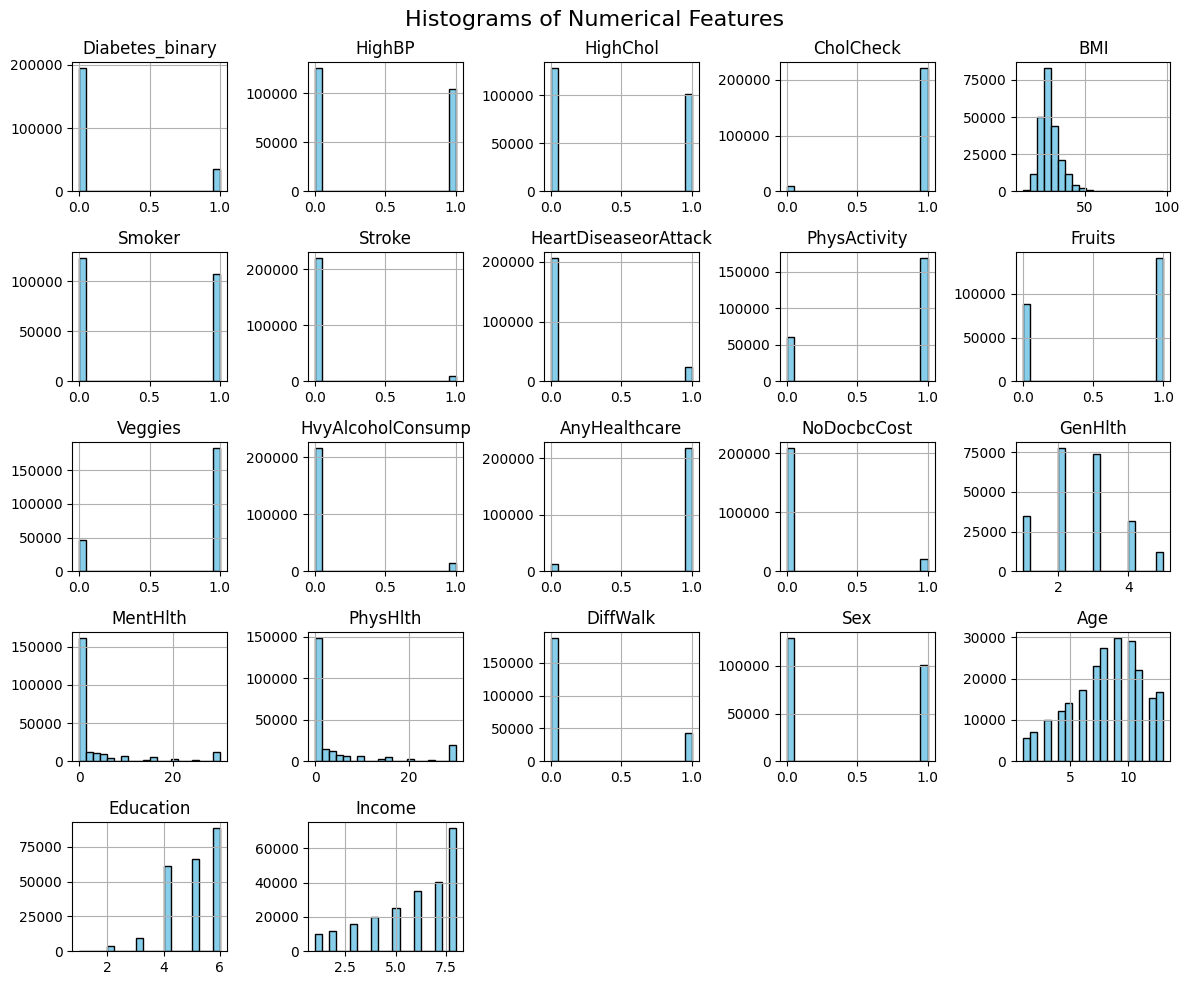

In [ ]:
#  Plot histograms for all numerical features
df.hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')

# Set the title for the overall figure
plt.suptitle("Histograms of Numerical Features", fontsize=16)

# Adjust layout so titles and labels don’t overlap
plt.tight_layout()

# Show the plot
plt.show()

**----------Findings-------------------**



*   Binary Features Dominance: Most features (e.g., Diabetes_binary, HighBP, HighChol, CholCheck, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsum, AnyHealthcare, NoDocbcCost, DiffWalk, Sex) have two distinct bars at 0 and 1. The majority of responses fall into one category (usually 0), demonstrating strong class imbalance across these health indicators with a larger number of negative cases than positives.

*   BMI Distribution: BMI is roughly right-skewed, with the majority of values concentrated between 20 and 40, suggesting most survey participants have BMI within the typical adult range, and fewer with extremely high values.

*   General Health & Health Days (GenHlth, MentHlth, PhysHlth): GenHlth shows five well-populated bins; MentHlth and PhysHlth have many values at zero, indicating most respondents report few issues, but there's a long tail of higher counts.

*   Age: The age feature is categorical and distributed across roughly 13 bins, with the distribution peaking in the middle bins, suggesting a concentration of middle-aged and older adults in the sample.

*   Education and Income: These features show a positive skew, with higher education and income levels more frequently reported, but lower ranges are also present.

*   Class Imbalance: Nearly all binary health indicator variables, such as 'Smoker', 'Stroke', or 'HeartDiseaseorAttack', show a sharp imbalance, a crucial modeling consideration for classification tasks.






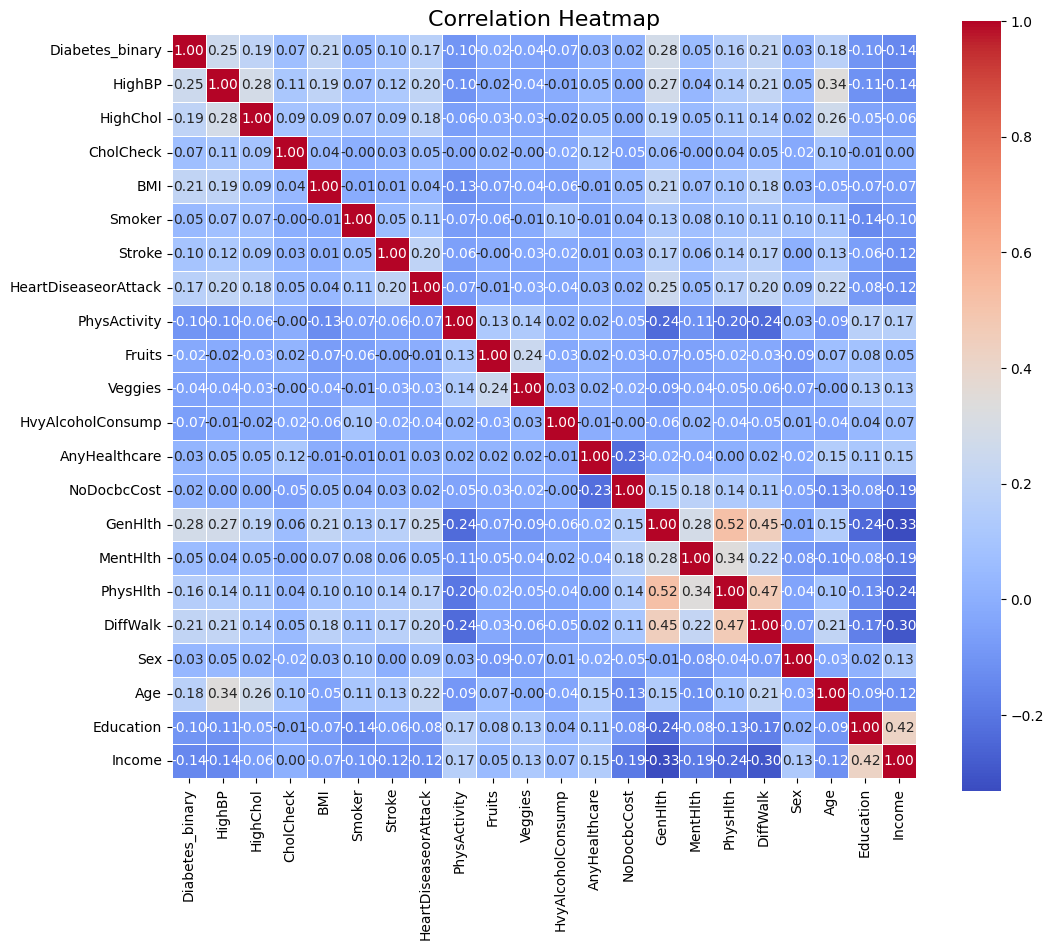

In [ ]:

# Compute the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12,10))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

# Title for the heatmap
plt.title("Correlation Heatmap", fontsize=16)

# Display the plot
plt.show()

**-----------Findingd------------**
* Low Overall Correlations: Most feature correlations are weak (mostly between -0.2 and 0.3), indicating little linear relationship between variables. There are no strong multicollinearity issues, making these features mostly independent for modeling.

* Diabetes_binary Associations: Diabetes_binary has its highest correlations with HighBP (0.25), HighChol (0.19), BMI (0.21), and Age (0.18). These are expected risk factors but none are strongly correlated, suggesting potential for prediction but no redundancy.

* Health Indicators Interrelated:

    * GenHlth is moderately correlated with PhysHlth (0.52), MentHlth (0.28), and DiffWalk (0.47). This means people reporting worse general health also tend to report more physical/mental health issues and walking difficulties.

    * PhysHlth and DiffWalk have a notable correlation (0.47), indicating overlap in respondents with poor physical health and mobility limitations.

* Socioeconomic Factors:

    * Education and Income are moderately correlated (0.42), demonstrating expected socioeconomic association.

* Protective Behaviors and Negative Correlations:

    * Age is negatively correlated with HighBP (-0.34), suggesting that within the surveyed bins, older age groups may have a lower prevalence possibly due to survival bias or binning effects.

    * Veggies and Fruits consumption have weak correlations with risk factors, indicating diet patterns are not strongly predictive within this data.


/tmp/ipython-input-820501855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Diabetes_binary", data=df, palette="Set2")


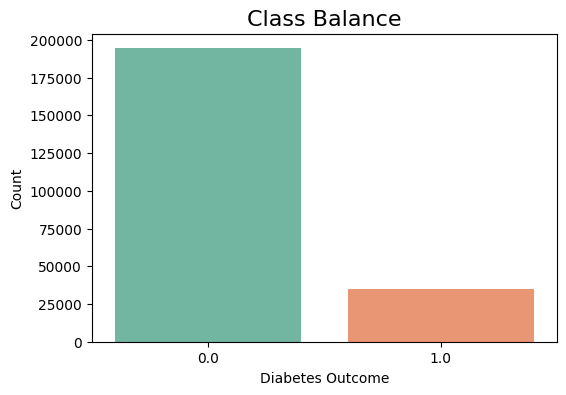

In [ ]:
# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Diabetes_binary", data=df, palette="Set2")
plt.title("Class Balance", fontsize=16)
plt.xlabel("Diabetes Outcome")
plt.ylabel("Count")
plt.show()

**---------Findings------------**

* The majority of samples are in the "0" class (no diabetes).

* The "1" class (diabetes) has far fewer samples.

* This severe imbalance means that about 84% of the data belongs to the non-diabetic class, while only 16% represents the diabetic class.

**-----------CHECKING IMBALANCED DATASET------------**

In [ ]:
# count of unique values in the "diabetic" column
df["Diabetes_binary"].value_counts()

In [ ]:
# Percentage Distribution of Diabetic vs Non-Diabetic Cases
df["Diabetes_binary"].value_counts(normalize=True) * 100

**-----------HANDLING IMBALANCED DATASET----------------**


In [ ]:
from imblearn.over_sampling import SMOTE
# Handle imbalanced dataset
# Features and target
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Convert back to DataFrame for inspection
X_res = pd.DataFrame(X_res, columns=X.columns)
y_res = pd.Series(y_res, name="Diabetes_binary")

# Show the new class distribution
print("Original dataset distribution:")
print(y.value_counts())

print("\nResampled dataset distribution:")
print(y_res.value_counts())
df = pd.concat([X_res, y_res], axis=1)

In [ ]:
# Re check Class distribution in percentage
df["Diabetes_binary"].value_counts(normalize=True) * 100

In [ ]:
df.shape

In [ ]:
df.duplicated().sum()

In [ ]:
df.drop_duplicates(inplace=True)

**-----------OUTLIER DETECTION------------**

In [ ]:
outliers = {}
print("\nOutliers\n------------")
for column in df.columns[:-1]:  # Exclude target
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outlier_indices = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index
  outliers[column] = list(outlier_indices)
  print(f"{column} : {len(outlier_indices)}")

**-----------HANDLE OUTLIERS-------------**

In [ ]:
# Function to cap outliers using IQR method
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].apply(
        lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
    )
    return df

# Apply to all numeric columns except target
for col in df.drop(columns=['Diabetes_binary']).columns:
    df = cap_outliers(df, col)

print("✅ Outliers treated (capped within IQR limits) and dataset saved as diabetes_outlier_treated.csv")

In [ ]:
df.to_csv('cleaned_diabetes.csv', index=False)